# MEA analysis walkthrough — `EyeMovementTrajectoryAlternatingBackground`

End-to-end tour of the MEA stack: ingest experiment metadata into DataJoint, survey what's in there, find every date that ran a given protocol, pick one, build a pipeline, and pull spike times into an `xarray` for a population plot.

Sections 1–5 are protocol-agnostic — change the search string in §4 and they work for any stimulus. Sections 6 onward use `EyeMovementTrajectoryAlternatingBackground` as the worked example: the protocol replays a natural-image eye-movement trajectory at two background scales, so `currentBackgroundScale` is the manipulated variable and `currentImageName` the other condition axis.

Per repo convention there is one notebook per protocol, so when adding a new protocol copy this notebook and rewrite §6 onward rather than appending another analysis here. Deeper analysis of this particular protocol (QC, per-cell archives, PSTHs by condition, spike-distance metrics) lives in `demos/analyzeEyeMovementTraj.ipynb`; this notebook stays a tour of the machinery.

## 1. Imports and setup

`retinanalysis` resolves its public API lazily, so this cell stays cheap — DataJoint is only pulled in when the first database-backed function is called, in §2.

In [1]:
import retinanalysis as ra
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os

## 2. Populate the database

Ingests every experiment found on the configured source volumes into DataJoint, and re-ingests any date whose meta/tags `.json` has been modified since it was added (source mtime vs `Experiment.date_added`).

Volumes are swept in read-priority order — **ChrisNewSSD → ChrisProSSD → NAS** — and the first drive holding a given date wins, so a duplicate copy sitting on a slower volume never re-triggers an ingest. `ra.ingest_source_dirs()` reports the `(h5, meta, tags)` triples that will actually be searched; a drive that isn't mounted silently drops out of the list. The order itself lives in `src/retinanalysis/config/config.ini`, one section per volume.

Safe to re-run: dates already in the database and unchanged on disk are skipped.

In [2]:
# Volumes that will be swept, in read-priority order (local SSDs before the NAS).
for h5_dir, meta_dir, tags_dir in ra.ingest_source_dirs():
    print(f'h5   : {h5_dir}\nmeta : {meta_dir}\ntags : {tags_dir}\n')

# Ingest new dates, and refresh any date whose json changed since it was added.
# Returns {'n_ingested', 'added', 'updated', 'skipped'}.
summary = ra.populate_database()

print(f"\nnewly added : {len(summary['added'])}")
print(f"refreshed   : {len(summary['updated'])}")
print(f"errored     : {len(summary['skipped'])}")

h5   : /Volumes/ChrisProSSD/data/h5
meta : /Volumes/ChrisProSSD/data/datajoint_testbed/mea/meta
tags : /Volumes/ChrisProSSD/data/datajoint_testbed/mea/tags



/Users/chrischen/opt/anaconda3/envs/retinanalysis/lib/python3.11/site-packages/datajoint/settings.py:979: UserWarning: No datajoint.json found. Using defaults and environment variables. Run `dj.config.save_template()` to create a template configuration.
  config = _create_config()


Ingest source: /Volumes/ChrisProSSD/data/h5
Could not find data directory for 20220405C.json
Could not find data directory for 20220406C.json
Could not find data directory for 20220412C.json
Could not find data directory for 20220420C.json
Could not find data directory for 20220426C.json
Could not find data directory for 20220518C.json
Could not find data directory for 20220526C.json
Could not find data directory for 20220531C.json
Could not find data directory for 20220607C.json
Could not find data directory for 20220705C.json
Could not find data directory for 20220712C.json
Could not find data directory for 20220726C.json
Could not find data directory for 20220809C.json
Could not find data directory for 20220816C.json
Could not find data directory for 20220818C.json
Could not find data directory for 20220829C.json
Could not find data directory for 20220909C.json
Could not find data directory for 20221006C.json
Could not find data directory for 20221024C.json
Could not find data direc

Experiments:   0%|          | 0/30 [00:00<?, ?it/s]

Already in database: 20260113C
Already in database: 20251112C
Already in database: 20251215C
Already in database: 20251022C
Already in database: 20260102C
Already in database: 20230111C
Already in database: 20251008C
Already in database: 20250121C
Already in database: 20251006C
Already in database: 20230214C
Already in database: 20250924C
Already in database: 20250514C
Already in database: 20230228C
Already in database: 20250429C
Already in database: 20250321C
Already in database: 20230313C
Already in database: 20250306C
Already in database: 20230502C
Already in database: 20230516C
Already in database: 20230725C
Already in database: 20231026C
Already in database: 20231220C
Already in database: 20240117C
Already in database: 20240130C
Already in database: 20240523C
Already in database: 20240801C
Already in database: 20220823C
Already in database: 20221101C
Already in database: 20221123C
Already in database: 20260318C

No experiments skipped due to errors.
No new sorting chunks found in 

## 3. What's in the database?

A read-only survey of everything §2 ingested, before narrowing to one protocol. The implementations live in `retinanalysis/utils/db_summary.py` so this section stays two calls.

The first cell answers three questions:

1. **How many recordings of each kind** — `ra.recording_counts()`, split by `Experiment.is_mea` into MEA arrays and single-cell patch experiments.
2. **Which species** — `ra.species_counts()`, from `Animal.species`. Recorded for most MEA dates but rarely for patch experiments, so expect a large `(not recorded)` row on the patch side; that means the field is blank, not that the animal is missing.
3. **Which protocols dominate the MEA corpus** — `ra.mea_protocol_counts()`, ranked by number of distinct dates rather than number of blocks. Dates is the more useful denominator: a protocol run four times in one day is still one day of data. Both counts are returned so the difference is visible.

The protocol table is rendered with `ra.scroll_table` rather than `display()`, so the **whole** list is there — a fixed-height box with a sticky header, scrolling only once the corpus outgrows it. It used to be truncated to `head(15)`, which hid exactly the long tail you go looking for when hunting a protocol you ran a handful of times. Raise `height=` for a taller box.

The second cell is `ra.browse_experiment_tree()` — a dropdown of every MEA date. Pick one and it renders that date's blocks as a **date → protocol → datafile** tree, indexed on those three levels so pandas blanks the repeated labels and the nesting shows: each date once, each protocol once beneath it, and the datafiles that ran it underneath. Columns are the group label, the filter-wheel reading, the sorting chunk and the block duration. `ra.experiment_tree('20231220C')` returns the same table directly when you already know the date and don't want the widget.

Protocol names are shortened to their last dotted component — `edu.washington.riekelab.turner.protocols.EyeMovementTrajectoryAlternatingBackground` becomes `EyeMovementTrajectoryAlternatingBackground`. The prefix only records which lab package the protocol came from and makes every table unreadable.

**On the filter wheel.** `filter_wheel_ndf` is the epoch parameter `NDF`. In this codebase those are the same thing — `populate_ndf_column` calls it "the filter wheel ND being used" and the single-cell code renames the identical field to `filter_wheel_ndf`, so the tree uses the explicit name. It is read from the first epoch of each block via a JSON extraction pushed into SQL, which is why a date loads in one query instead of one per block.

In [3]:
# Whole-database survey. Each helper is one bulk query joined in pandas —
# implementations live in retinanalysis/utils/db_summary.py.
display(ra.recording_counts().to_frame('experiments'))

print('Species (experiments):')
display(ra.species_counts())

protocol_counts = ra.mea_protocol_counts()
print(f'{len(protocol_counts)} distinct protocols across MEA dates, '
      f'ranked by number of dates:')

# Every protocol, not a head(15) truncation: scroll_table caps the box height
# and pins the header row, so the list only scrolls once it outgrows the box.
ra.scroll_table(protocol_counts.reset_index(), height = 420,
                num_cols = ('n_dates', 'n_blocks'));

,experiments
MEA,210
patch,523
total,733


Species (experiments):


rig,MEA,patch
species,,
(not recorded),34,512
M. fascicularis,18,5
M. mulatta,46,2
M. nemestrina,112,4


84 distinct protocols across MEA dates, ranked by number of dates:


protocol,n_dates,n_blocks
ContrastResponseGrating,160,764
SpatialNoise,144,639
MovingChromaticBar,124,251
ObjectMotionDots,87,154
GratingDSOS,80,107
PresentImages,72,178
ChirpStimulus,65,110
FastNoise,64,356
DovesMovie,60,127
SparseNoise,57,91


In [ ]:
# Dropdown of every MEA date; picking one loads that date's block tree.
# Without the GUI, for a date you already know:  ra.experiment_tree('20231220C')
ra.browse_experiment_tree();

## 4. Find datasets that ran the protocol

`get_datasets_from_protocol_names` does a lowercase substring match against the protocol names in the database, so the short query `'AlternatingBackground'` picks out the full Java class name `edu.washington.riekelab.turner.protocols.EyeMovementTrajectoryAlternatingBackground` without you typing it. Searching `'eyemovement'` instead would also catch five unrelated protocols, so keep the query specific. The result is one row per epoch block, so a date that ran the protocol twice appears twice.

Two columns are added on top of the raw search. The dates are filtered to those with Vision analysis output on a mounted volume, and `ss_version` reports the Kilosort version each chunk actually has — `kilosort2.5` where present, otherwise `kilosort2`.

**Read the `ss_version` column before picking anything in §5.** `not found` means that chunk is on no configured volume, and it's the common case here: of the 31 blocks, only 17 have a loadable chunk. The date-level filter above can't catch this, because a date directory can exist while the specific chunk inside it does not.

The `experiment_id` / `protocol_id` / `group_id` / `block_id` / `chunk_id` columns are still on `exp_search` for anything downstream that needs them — the display is just narrowed to `SEARCH_COLS`. Widen that list, or `display(exp_search)`, to see everything.

In [4]:
exp_search = ra.get_datasets_from_protocol_names('variableMeanDriftingGrating')

# Keep only dates whose Vision analysis output is on a mounted volume. tier_dirs
# returns every configured analysis root, so this spans both SSDs and the NAS
# rather than only checking the top-priority one.
available_experiments = sorted({exp for root in ra.tier_dirs('analysis')
                                for exp in os.listdir(root)})
exp_search = exp_search.query('exp_name in @available_experiments').reset_index(drop = True)

# Kilosort version actually on disk for each chunk. 'not found' means the chunk
# is on no configured volume, so §5 cannot render it — the date directory
# existing is not enough.
exp_search = ra.add_ss_version_column(exp_search)

# The experiment_id / protocol_id / group_id / block_id / chunk_id columns stay
# on exp_search for downstream code; they are just noise on screen.
SEARCH_COLS = ['exp_name', 'datafile_name', 'chunk_name', 'ss_version',
               'NDF', 'group_label']
print(exp_search['ss_version'].value_counts().to_string())
display(exp_search[SEARCH_COLS])


Found 2 protocols matching "variablemeandriftinggrating":
['edu.washington.riekelab.chris.protocols.variableMeanDriftingGrating'
 'edu.washington.riekelab.vyom.protocols.variableMeanDriftingGrating']

Found 7 experiments, 8 epoch blocks.

ss_version
kilosort2    5


,exp_name,datafile_name,chunk_name,ss_version,NDF,group_label
0,20221123C,data028,chunk4,kilosort2,2.0,CC var mean drift grating
1,20230214C,data019,chunk3,kilosort2,3.0,var mean drift grating ndf 3.0
2,20230214C,data023,chunk3,kilosort2,3.0,var mean drift grating ndf 3.0
3,20230313C,data018,chunk2,kilosort2,3.0,Var Mean Drift Grating ndf 3.0
4,20230502C,data017,chunk2,kilosort2,3.0,ndf 3.0 var mean drift grating


## 5. Plot mosaics for candidate datasets

RF mosaics for the datasets you name, so you can judge which experiment has the cleanest typing before committing to one. Set `MOSAIC_ENTRIES` to row indices from the §4 table — pick rows whose `ss_version` isn't `not found`, since those have no chunk on any volume.

The second cell says what is actually *in* each mosaic, which the pictures alone won't tell you. First a table from `cell_type_summary`:

- **Cells per type.** A mosaic can look tidy while resting on four cells. It also lists the types you didn't ask for (`Unknown`, `OffMystery`, …), which is useful context — on `20231220C/chunk4` the largest single group is 286 `Unknown` cells against 116 `OffP`.
- **Firing rate per type**, as mean/median/min/max. This is the mean rate across the whole noise chunk, so it's a data-quality number, not a response measure. A type whose rates sit near zero is usually a sorting artifact rather than a population.

Then `ra.plot_chunk_panels` draws the three views a spatial mosaic can't give you, one column per cell type in `MAIN_TYPES` order so the columns line up with the mosaic above:

- **Temporal RF** — the green-channel STA time course, every cell in a dim line with the mean ± SEM over the top, on a 500 ms axis ending at the spike. This is where a mislabeled type shows itself: an `OnP` group whose mean filter is flat, or inverts, was never a population no matter how regular its mosaic looks. Green is the channel plotted because the noise here is achromatic — red and green are identical — and one trace per type keeps the four columns comparable.
- **Autocorrelation (ISI)** — Vision's autocorrelation histogram, sum-normalized per cell so a fast-firing cell doesn't dominate the mean. Read the left edge first: density at lags under ~2 ms is a refractory-period violation, which means the cluster merges more than one unit. A clean type dips to zero at zero lag and peaks at that type's preferred interval.
- **Spike count over the noise run** — one ECDF across all types, total spikes per cell. This is the "how much data is behind each STA" view, and it's the number that matters for whether an RF fit means anything; the rate columns in the table above are the same quantity divided by chunk duration, which is what you want when comparing chunks of different length instead.

The count distribution is drawn as an **ECDF rather than a histogram**, because a well-populated type here has ~100 cells and a marginal one has three, and at those counts a histogram's shape is mostly an artifact of where the bins fell. An ECDF is exact at any n — one step per cell — so a sparse type overlaid on a dense one stays honest, and curves separate vertically instead of occluding each other. Read it as: further right means more spikes, steeper means the type is more tightly clustered. The x axis is logarithmic because counts run over orders of magnitude between types; pass `log_x=False` for a linear one.

`ra.plot_spike_count_distribution` and `ra.plot_firing_rate_distribution` draw the bottom panel on its own if you want just that one.

**The noise chunk is picked by recording time, preferring one recorded before the protocol.** A chunk that ran afterwards has an intervening protocol's worth of adaptation between it and the data being typed, so it's used only when no preceding chunk works — even if the clock distance is shorter. Candidates lacking a typing file are skipped, so `20220823C` still falls through to a following chunk (only `chunk5` has an analysis dir at all); the printout says "before" or "after" so you can see when that happened. This is the same rule §7 uses, so the mosaic you judge here and the chunk the analysis runs on agree.

Sort versions are resolved per chunk, and the analysis directory is looked up with `find_path`, which walks the volumes in read-priority order — so a chunk that only exists on the NAS is found there when ChrisProSSD doesn't have it. A chunk missing everywhere is reported and skipped rather than aborting the sweep.

,exp_name,datafile_name,chunk_name,ss_version,NDF,group_label
0,20221123C,data028,chunk4,kilosort2,2.0,CC var mean drift grating
1,20230214C,data019,chunk3,kilosort2,3.0,var mean drift grating ndf 3.0
2,20230214C,data023,chunk3,kilosort2,3.0,var mean drift grating ndf 3.0
3,20230313C,data018,chunk2,kilosort2,3.0,Var Mean Drift Grating ndf 3.0
4,20230502C,data017,chunk2,kilosort2,3.0,ndf 3.0 var mean drift grating


Found 3 noise chunks for protocol "manookinlab.protocols.FastNoise"
Noise chunks in preference order (preceding first):
  chunk4: 93.07 minutes before the protocol
  chunk2: 238.55 minutes before the protocol
  chunk1: 397.07 minutes before the protocol
Loading VCD from /Users/chrischen/.cache/retinanalysis/analysis/20221123C/chunk4/kilosort2 ...
VCD loaded with 917 cells.

32 of 917 cells have no STA fit (in .neurons but not .params); excluding them.
20221123C/chunk4: loaded kilosort2 from /Users/chrischen/.cache/retinanalysis/analysis/20221123C/chunk4
Found 3 noise chunks for protocol "manookinlab.protocols.FastNoise"
Noise chunks in preference order (preceding first):
  chunk2: 58.15 minutes before the protocol
  chunk1: 197.08 minutes before the protocol
  chunk3: 89.12 minutes after the protocol
Loading VCD from /Volumes/ChrisProSSD/analysis/20230214C/chunk2/kilosort2 ...
VCD loaded with 1524 cells.

1 of 1524 cells have no STA fit (in .neurons but not .params); excluding them.

2

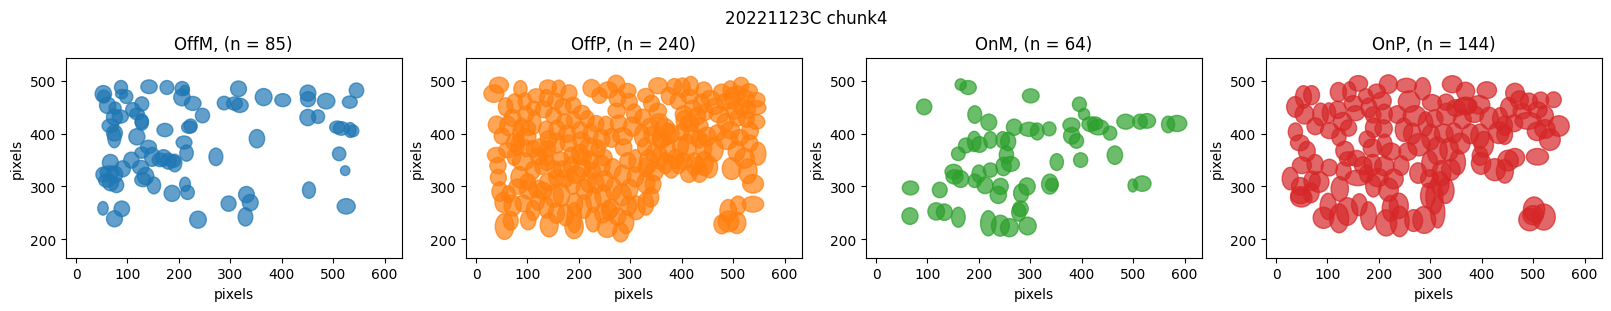

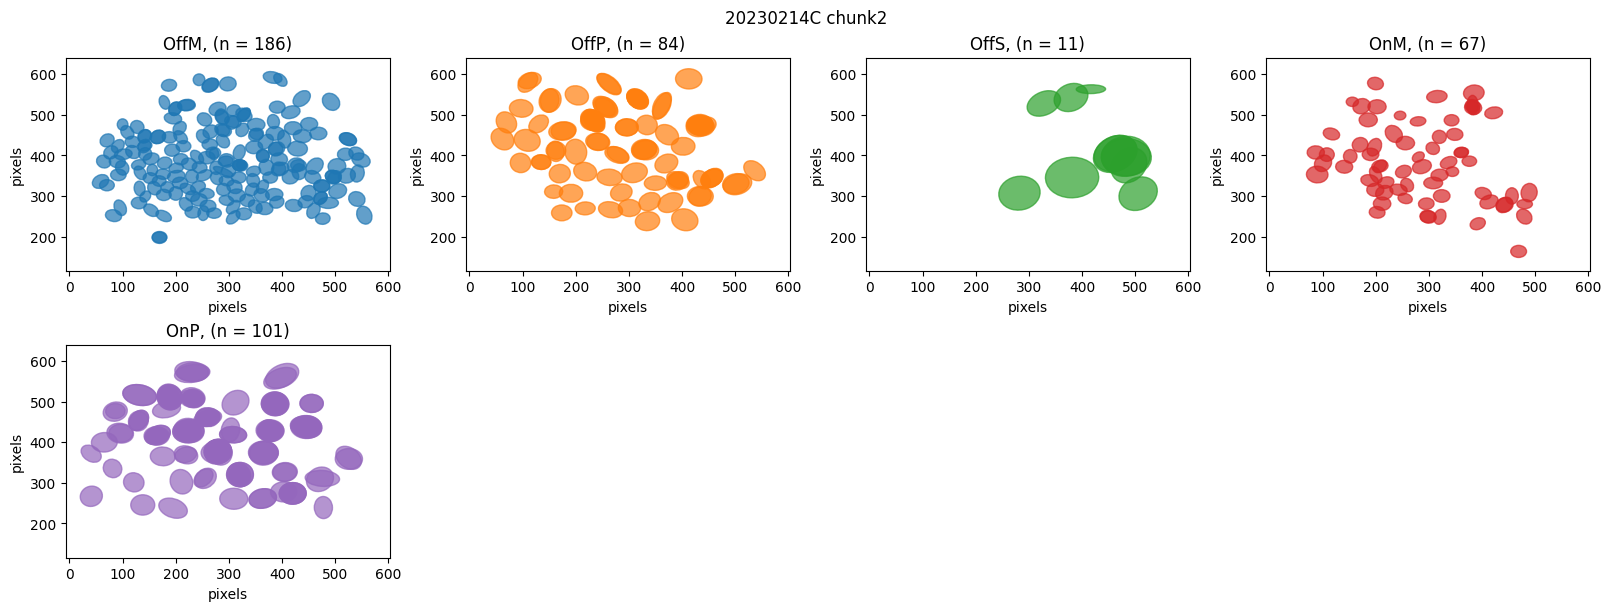

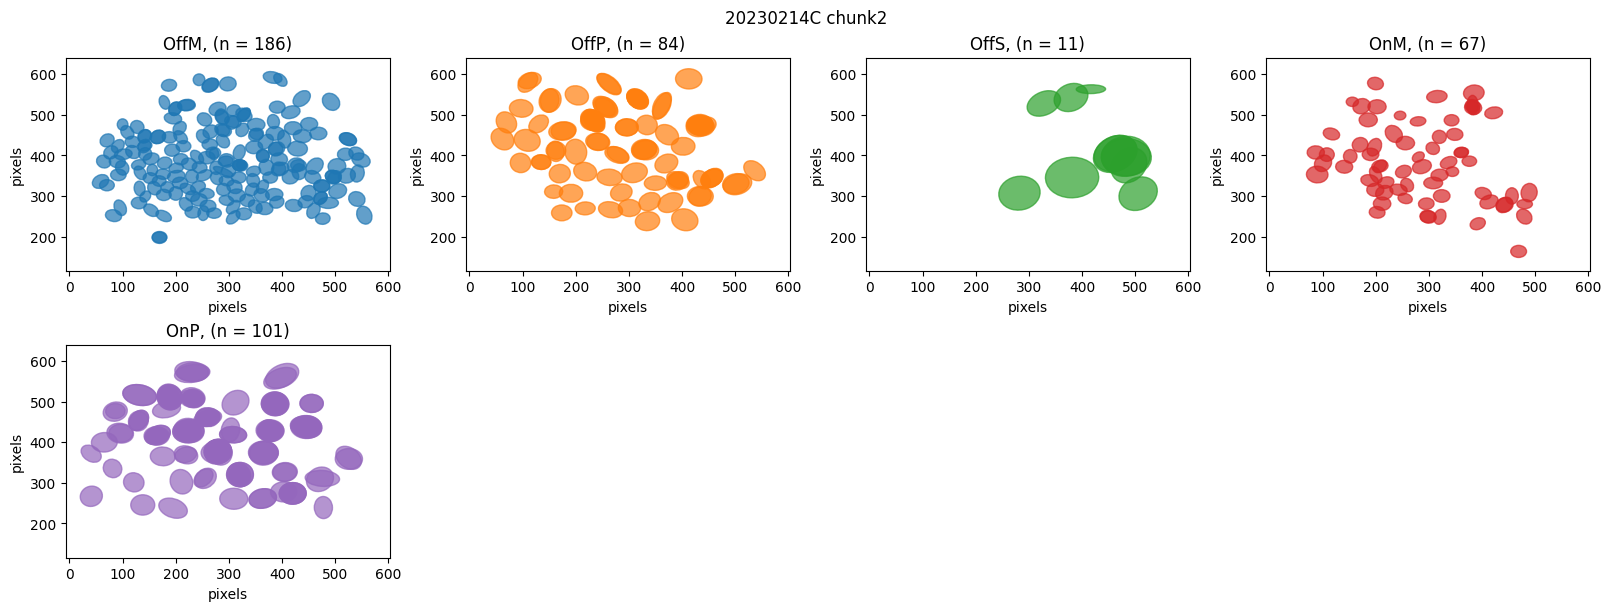

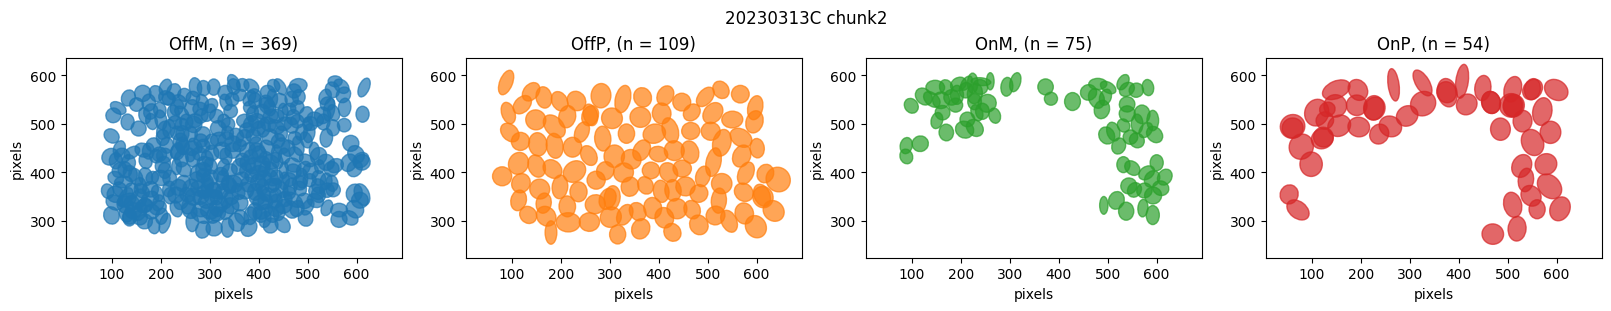

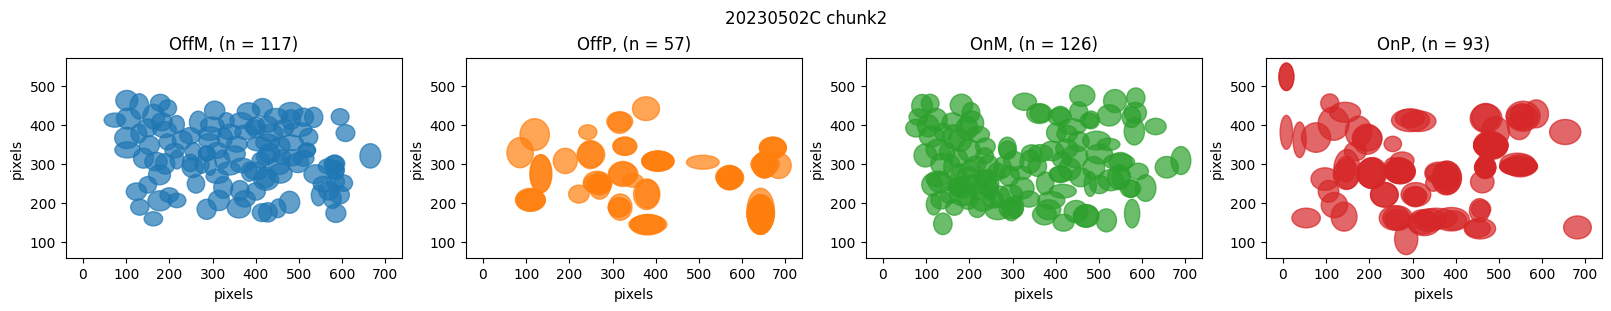

In [6]:
cell_types = ['OnP', 'OffP', 'OnM', 'OffM', 'A2', 'OnS', 'OffS']

# <-- EDIT ME: row indices from the §4 table. Pick rows whose ss_version is not
# 'not found'; each costs one Vision analysis-chunk read.
MOSAIC_ENTRIES = [0, 1,2,3,4]

mosaic_search = exp_search.loc[MOSAIC_ENTRIES]
display(mosaic_search[SEARCH_COLS])

# include_neurons pulls the spike times too, which the next cell needs for
# firing rates; return_chunks hands back the loaded chunks so that summary
# doesn't have to read them a second time.
all_axes, chunks = ra.plot_mosaics_for_datasets(
    mosaic_search, cell_types, minimum_n = 3, b_zoom = True,
    include_neurons = True, return_chunks = True)

=== 20221123C/chunk4 (kilosort2) ===


,n_cells,mean_rate_hz,median_rate_hz,min_rate_hz,max_rate_hz,mean_spikes
cell_type,,,,,,
Unknown,310,1.38,0.65,0.00,17.12,7089
OffP,240,10.63,10.41,0.36,29.76,54530
OnP,144,9.98,9.81,0.68,18.12,51176
OffM,85,4.17,3.41,0.13,24.74,21393
OnM,64,3.81,3.82,0.25,9.22,19528
OffMystery,22,3.23,2.31,0.38,10.42,16560
OnMystery,20,5.57,1.52,0.42,17.21,28580


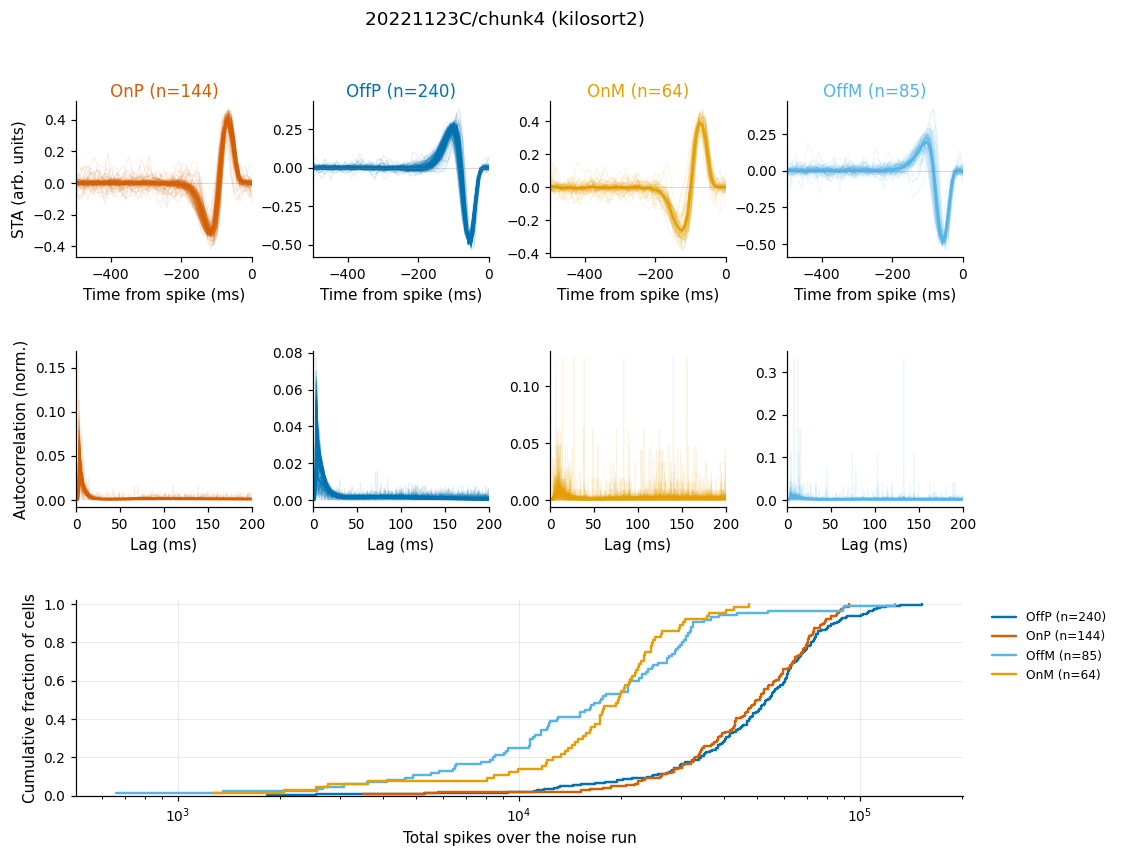

=== 20230214C/chunk2 (kilosort2) ===


,n_cells,mean_rate_hz,median_rate_hz,min_rate_hz,max_rate_hz,mean_spikes
cell_type,,,,,,
Unknown,974,1.17,0.12,0.00,26.98,7466
OffM,186,2.16,1.73,0.06,9.99,13821
OnP,101,1.68,1.32,0.02,7.90,10778
OffP,84,6.35,6.65,0.45,13.60,40693
OnM,67,1.21,0.50,0.03,6.39,7775
OffMystery,45,2.76,2.06,0.13,12.29,17704
OffAmacrine,41,1.08,0.92,0.24,5.40,6952
A1,13,1.91,1.98,0.06,3.88,12224
OffS,11,4.00,2.98,0.67,9.73,25639


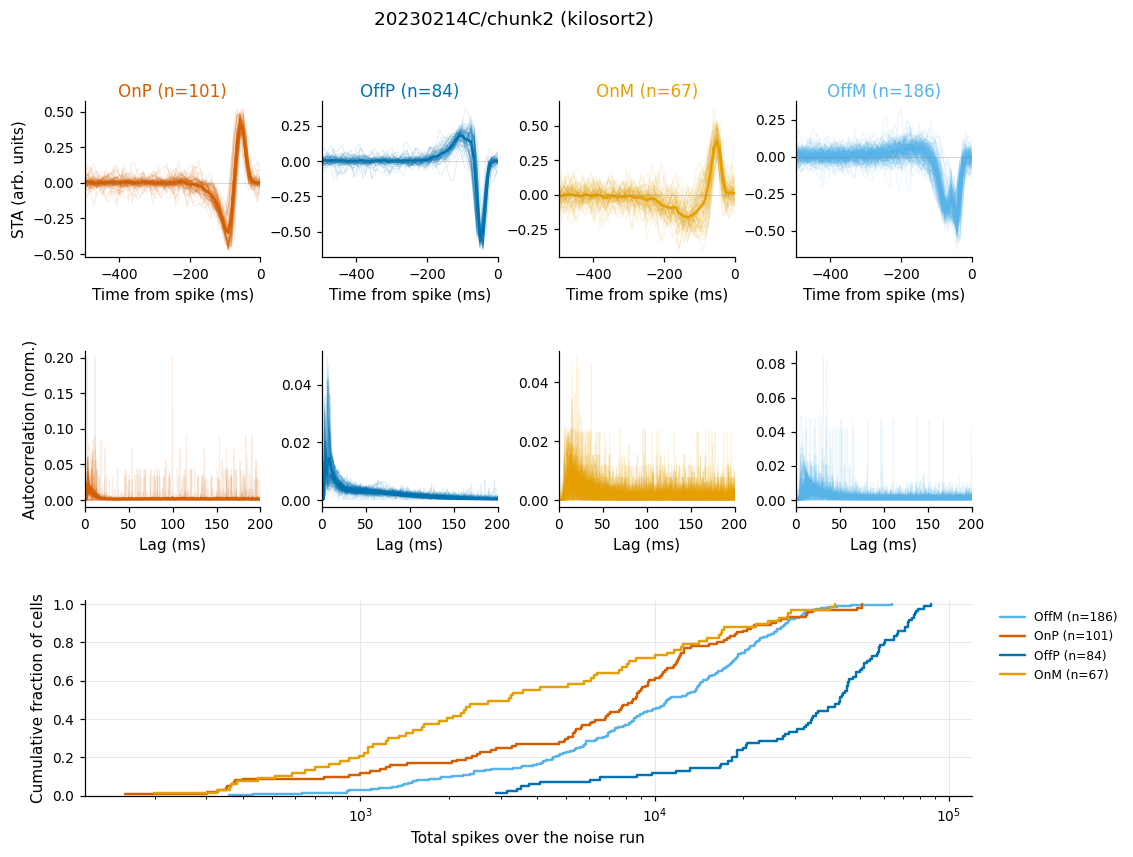

=== 20230313C/chunk2 (kilosort2) ===


,n_cells,mean_rate_hz,median_rate_hz,min_rate_hz,max_rate_hz,mean_spikes
cell_type,,,,,,
Unknown,753,2.77,0.72,0.00,33.55,18712
OffM,369,3.35,2.79,0.09,10.41,22625
OffP,109,5.30,4.94,0.18,12.04,35765
OnM,75,4.64,4.20,0.33,15.75,31309
OffMystery,58,1.67,1.22,0.11,10.46,11301
OnP,54,5.84,4.85,0.26,14.41,39442
Amacrine,21,1.70,1.58,0.42,5.02,11481
A1,21,2.13,1.88,0.12,4.07,14364
OnMystery,16,5.93,5.76,0.31,11.53,39997


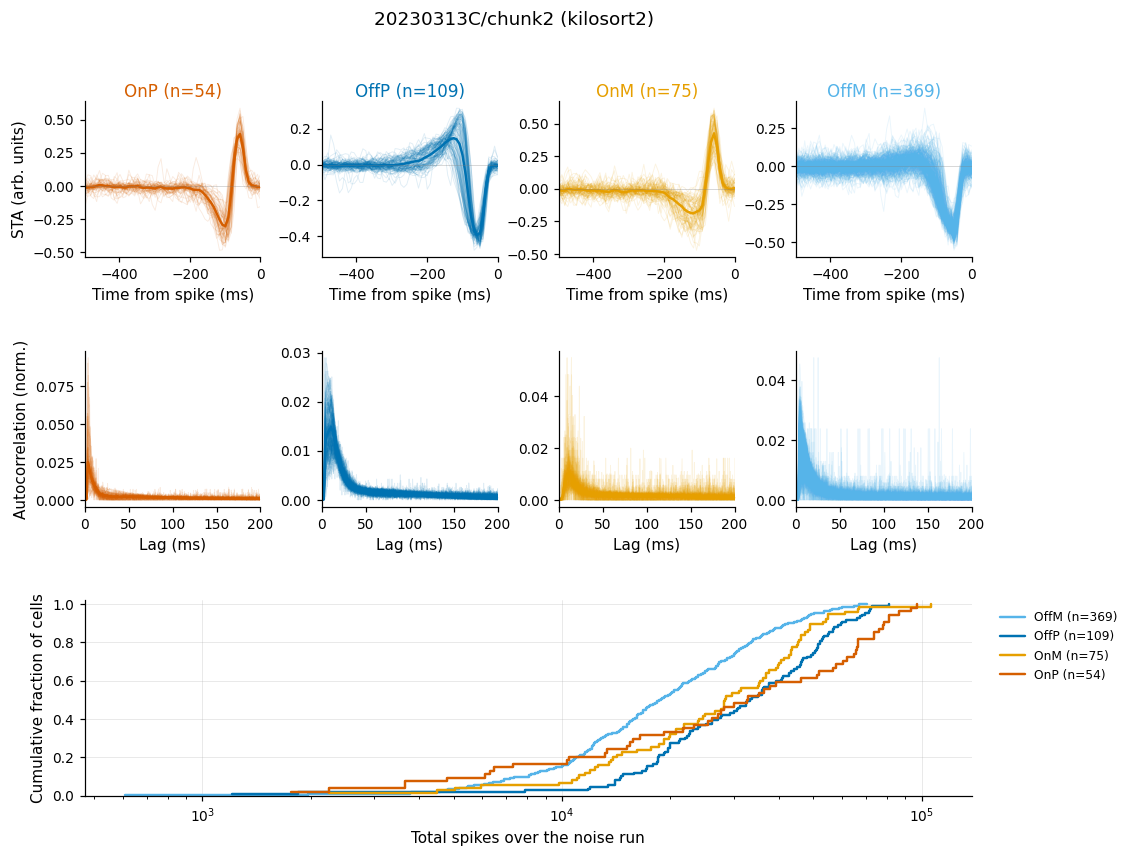

=== 20230502C/chunk2 (kilosort2) ===


,n_cells,mean_rate_hz,median_rate_hz,min_rate_hz,max_rate_hz,mean_spikes
cell_type,,,,,,
Unknown,310,0.89,0.21,0.00,17.31,7925
OnM,126,8.99,9.66,0.07,19.70,79624
OffM,117,4.51,4.00,0.09,19.10,39921
Amacrine,94,1.20,0.90,0.04,5.68,10660
OnP,93,5.19,4.07,0.05,24.05,45977
OffP,57,3.25,2.80,0.01,14.94,28737


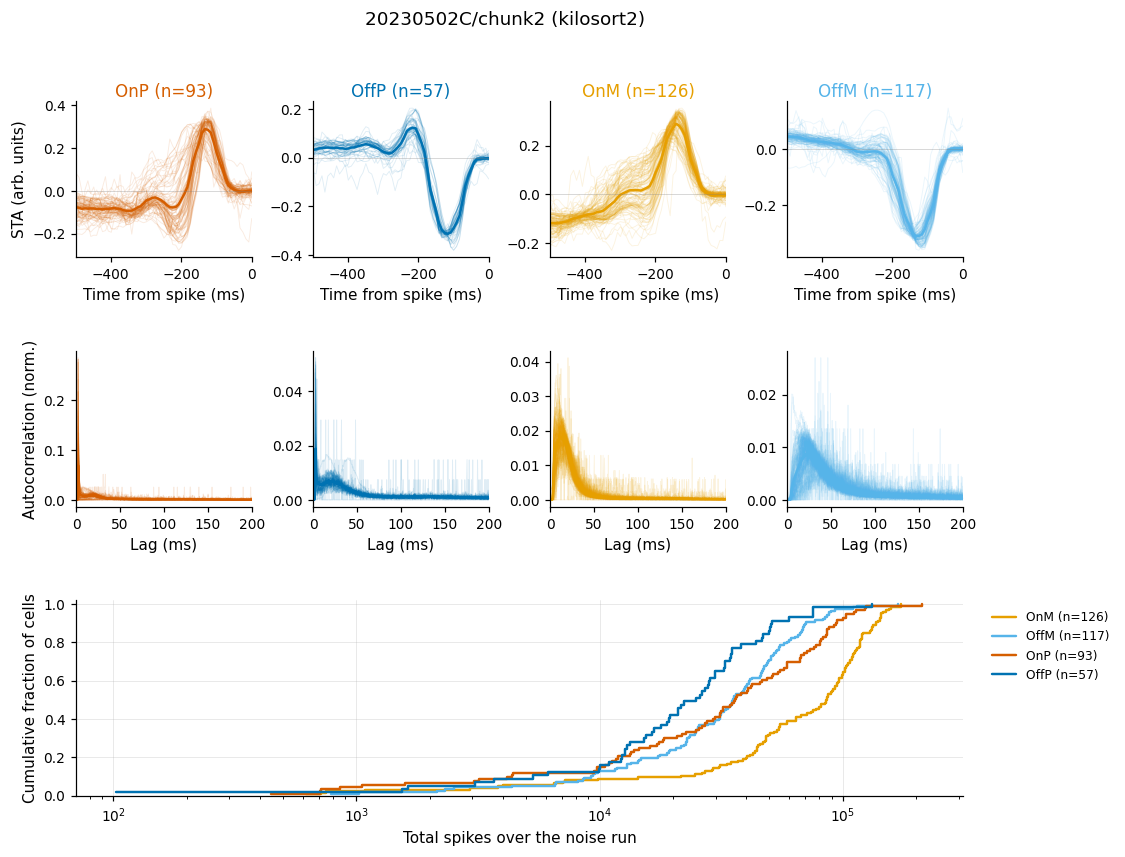

In [7]:
# What is actually in each mosaic: cells per type, and how hard they fire.
MAIN_TYPES = ['OnP', 'OffP', 'OnM', 'OffM']

for key, chunk in chunks.items():
    print(f'=== {key} ({chunk.ss_version}) ===')
    display(ra.cell_type_summary(chunk, minimum_n = 3))

    # Everything the spatial mosaic can't show: temporal RF and autocorrelation
    # per type, plus total spikes per cell over the noise run. Columns follow
    # MAIN_TYPES, so they line up with the mosaic above.
    ra.plot_chunk_panels(chunk, cell_types = MAIN_TYPES, minimum_n = 3,
                         title = f'{key} ({chunk.ss_version})')
    plt.show()

## 6. Choose an experiment

Pick a row from the table in §4. Several dates ran this protocol more than once (`20231220C` has both `data022` and `data023`, `20221101C` has three), so the datafile has to be named alongside the date — selecting on `exp_name` alone would match multiple rows.

The default here is `20231220C / data022`, which lives on the local SSD rather than the NAS and so loads quickly in §7.

`get_exp_summary` then lists every block recorded that day with its duration, chunk name and start time — the same call §3 used to build its tree, shown flat here for the one chosen date.

In [ ]:
exp_name      = '20231220C'   # <-- EDIT ME: exp_name from the §4 table
datafile_name = 'data022'     # <-- EDIT ME: this date ran the protocol twice

# Select on both columns: .item() on an exp_name-only query would raise for any
# date with more than one block of this protocol.
entry = exp_search.query('exp_name == @exp_name and datafile_name == @datafile_name')
assert len(entry) == 1, f'expected 1 row for {exp_name}/{datafile_name}, got {len(entry)}'

chunk_name = entry['chunk_name'].item()
print(f'Using datafile {datafile_name} (nearest noise chunk {chunk_name}) '
      f'from experiment {exp_name}')

experiment_summary = ra.get_exp_summary(exp_name)
display(experiment_summary)

## 7. Initialize the analysis pipeline

Builds the three objects the rest of the notebook runs on: the stimulus block, the response block (spike times from the Kilosort output), and the noise `AnalysisChunk` (STAs and EIs). It then cluster-matches the protocol's cells against that noise chunk so noise-derived cell types carry over to the protocol datafile.

**The noise chunk is chosen the same way as in §5** — nearest by recording time, preferring one that ran *before* the protocol. Candidates without a typing file are skipped, so a date can still fall through to a following chunk; the printout says which it was and how many minutes away, so you can see when that happened.

**The Kilosort version is resolved, not assumed.** It used to default to `kilosort2.5`, which made every `kilosort2`-only date fail with an unhelpful "is not a folder" assertion. Both trees are now detected independently — the sorted-data tree for the response block and the analysis tree for the chunk, since they live on different volumes and can differ — taking `kilosort2.5` when present and falling back to `kilosort2`. Pass `ss_version=...` to pin it if you need a specific sort.

Two things in the printout are worth reading: how far away the chosen noise chunk was recorded, and the cluster-match rate. A chunk recorded hours from the protocol matches worse, and a low match rate is the usual explanation for a cell type looking scattered in §8.

In [ ]:
pipeline = ra.create_mea_pipeline(exp_name, datafile_name)

## 8. Compare protocol RFs against noise RFs

Two sets of mosaics over the same cell types: the first from cells as matched into the protocol datafile, the second straight from the noise chunk they were typed in.

They should look substantially the same. A type that is well-formed in the noise mosaic but scattered in the protocol one is a cluster-matching failure, not biology — go back to §7 and check the match rate before trusting anything downstream.

In [ ]:
protocol_rfs = pipeline.plot_rfs(cell_types = cell_types, minimum_n = 3, b_zoom = True)
noise_rfs = pipeline.analysis_chunk.plot_rfs(cell_types = cell_types, minimum_n = 3,
                                             b_zoom = True)

## 9. Break out the underlying objects

`MEAPipeline` is a thin container over three members. Pulling them into their own names keeps the rest of the notebook readable — everything below works directly off `stim_block`, `response_block` and `analysis_chunk`.

In [ ]:
stim_block = pipeline.stim
response_block = pipeline.resp
analysis_chunk = pipeline.analysis_chunk

## 10. Inspect the stimulus table

`df_epochs` is one row per epoch. For this protocol the two condition axes are `currentImageName` (which natural image's eye-movement trajectory was replayed) and `currentBackgroundScale` (how the surround was scaled), and the block cycles through every image × scale combination.

`currentBackgroundScale` is not always promoted to its own `df_epochs` column — whether it appears depends on the protocol version that recorded the date — so the cell falls back to reading the raw `epoch_parameters` dicts, the same pattern `retinanalysis.regen.eye_movement_alt_bg` uses. Read the per-epoch values rather than assuming the column is there.

`d_epoch_block_params` holds what was fixed for the whole block: `preTime`, `stimTime`, `tailTime`, and the `backgroundScale` list. The per-epoch `background_scale` array pulled out here is what groups epochs by condition in §12.

In [ ]:
stimulus_data = stim_block.df_epochs
display(stimulus_data)

epoch_block_params = stim_block.d_epoch_block_params


def epoch_param(df, key, dtype = float):
    """Per-epoch values for `key`, from its column if promoted, else the raw dicts."""
    if key in df.columns:
        return df[key].to_numpy(dtype = dtype)
    return np.array([p.get(key) for p in df['epoch_parameters']], dtype = dtype)


# The two condition axes. currentBackgroundScale is the manipulated variable;
# currentImageName says which natural image the trajectory was drawn from.
background_scale = epoch_param(stimulus_data, 'currentBackgroundScale')
image_name       = epoch_param(stimulus_data, 'currentImageName', dtype = str)

# Block-level list of scales, falling back to whatever the epochs actually used.
all_background_scales = np.unique(
    np.asarray(epoch_block_params.get('backgroundScale',
                                      np.unique(background_scale)), dtype = float))

print(f'{len(stimulus_data)} epochs')
print(f'background scales : {all_background_scales}')
print(f'images            : {sorted(set(image_name))}')

## 11. Pull spike times and spike counts

`get_spike_xarr` returns a ragged `xarray.DataArray` over (`cell_id` × `epoch`), where each element is the array of spike times in ms relative to epoch start. `apply_ufunc(len, ...)` collapses that to a total spike count per cell per epoch.

The same trick with `get_avg_baseline` counts only the spikes that landed before `preTime`, giving a per-cell, per-epoch baseline rate to subtract in §12.

In [ ]:
spike_times = ra.get_spike_xarr(response_block, cell_types = cell_types, minimum_n = 3)
spike_counts = xr.apply_ufunc(len, spike_times, vectorize = True)

# Bonus: Use apply_ufunc to pull the average baseline spike count from the 'pre time' portion of the stimulus
def get_avg_baseline(arr, pre_time):
    pre_spikes = [spike for spike in arr if spike < pre_time]

    return len(pre_spikes)

pre_time = epoch_block_params['preTime']
baseline_spike_counts = xr.apply_ufunc(get_avg_baseline, spike_times, 
                                       kwargs = {'pre_time' : pre_time},
                                       vectorize = True)


## 12. Spike count vs background scale

Baseline-subtracted mean spike count per cell type, split by `currentBackgroundScale`. This is the population-level version of the question the protocol asks: does scaling the surround change how strongly a cell type responds to the same eye-movement trajectory?

The form is a grouped bar chart rather than a line, because `backgroundScale` has only two levels here — a line between two points implies a continuum that wasn't sampled. Background scale is ordered low → high, so it gets two steps of the sequential cividis ramp via `ra.colors_for_conditions` (from `retinanalysis.utils.style`, the package's single source of truth for color). Cell type is named directly on the x-axis, so it needs no color of its own and no second legend.

Baseline is subtracted per cell before averaging, not as one grand mean per type — a cell with a high spontaneous rate would otherwise drag the whole type's mean. Error bars are the standard error across cells within a type. Cell types are re-derived from the spike array, so any type dropped by `minimum_n` in §11 never reaches the axis.

In [ ]:
ra.apply_publication_style()

# Cell types that survived into the spike array.
cell_types = sorted(np.unique(spike_times.coords['cell_type'].values))

# backgroundScale is ordered low -> high, so it gets the sequential cividis ramp.
scale_colors = ra.colors_for_conditions(list(all_background_scales))

fig, ax = plt.subplots(figsize = (1.1 * len(cell_types) + 2.5, 3.4))

n_scales  = len(all_background_scales)
group_pos = np.arange(len(cell_types), dtype = float)
bar_w     = 0.8 / n_scales

for s_idx, scale in enumerate(all_background_scales):
    means, sems = [], []

    for ct in cell_types:
        ct_counts   = spike_counts.where(spike_counts.cell_type == ct, drop = True)
        ct_baseline = baseline_spike_counts.where(
            baseline_spike_counts.cell_type == ct, drop = True)

        # Baseline is a per-cell property, so subtract it per cell before
        # averaging across the population rather than subtracting one grand mean.
        epoch_sel = ct_counts.epoch[background_scale == scale]
        per_cell  = (ct_counts.sel(epoch = epoch_sel).mean(dim = 'epoch', skipna = True)
                     - ct_baseline.mean(dim = 'epoch', skipna = True))

        vals = np.asarray(per_cell.values, dtype = float)
        vals = vals[np.isfinite(vals)]
        means.append(np.mean(vals) if vals.size else np.nan)
        sems.append(np.std(vals, ddof = 1) / np.sqrt(vals.size)
                    if vals.size > 1 else 0.0)

    # White edge leaves a small gap between the paired bars so they stay
    # readable when the two conditions land at similar heights.
    offset = (s_idx - (n_scales - 1) / 2) * bar_w
    ax.bar(group_pos + offset, means, bar_w * 0.92,
           yerr = sems, capsize = 2.5,
           color = scale_colors[scale], edgecolor = 'white', linewidth = 0.8,
           error_kw = {'linewidth': 0.8, 'ecolor': '#444444'},
           label = f'{scale:g}')

# Cell type is directly labeled on the axis, so only background scale needs a
# legend. Tick labels stay in default ink — series colors on text would fail
# contrast for the lighter cell-type hues.
ax.axhline(0, color = '#444444', linewidth = 0.8)
ax.set_xticks(group_pos)
ax.set_xticklabels(cell_types)

ax.set_xlabel('Cell type')
ax.set_ylabel('Baseline-subtracted spike count')
ax.set_title(f'{exp_name} {datafile_name} — response by background scale')
ax.legend(title = 'Background scale', bbox_to_anchor = [1.02, 1], loc = 'upper left')
ax.grid(True, axis = 'y', linewidth = 0.5, alpha = 0.35)
ax.set_axisbelow(True)

fig.tight_layout();